In [1]:
import pybedtools
from pybedtools import BedTool
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import fisher_exact

load specific files

In [2]:
genome = 'GRCh38_EBV.chrom.sizes.tsv'

hot_loci_name = 'hot_regions.clean.bed'
h3k4me3_name = 'K562_H3K4me3.bed'
h3k27ac_name = 'K562_H3K27ac.bed'
h3k27me3_name = 'K562_H3k27me3.bed'
h3k9me3_name = 'K562_H3K9me3.bed'

hot = BedTool(hot_loci_name).sort(g=genome)
marks = {
    'H3K4me3': BedTool(h3k4me3_name).sort(g=genome),
    'H3K27ac': BedTool(h3k27ac_name).sort(g=genome),
    'H3K27me3': BedTool(h3k27me3_name).sort(g=genome),
    'H3K9me3': BedTool(h3k9me3_name).sort(g=genome),
}

n_hot = hot.count()

print(n_hot, 'hot regions')
for name, bt in marks.items():
    print(bt.count(), name, 'peaks')

5990 hot regions
21445 H3K4me3 peaks
52334 H3K27ac peaks
163784 H3K27me3 peaks
5584 H3K9me3 peaks


blacklist-filter the full locus set -- this is the consistent universe every mark's 2x2 table gets built from below, not just a step toward the later occupancy-bin design

In [3]:
blacklist = BedTool('hg38-blacklist.v2.bed.gz').sort(g=genome)
df = pd.read_csv('merged_tf_counts.bed', sep='\t',
                 names=['chrom', 'start', 'end', 'tfs', 'n_tfs'])
df = df.reset_index().rename(columns={'index': 'locus_id'})

loci_bt = BedTool.from_dataframe(df[['chrom', 'start', 'end', 'locus_id']]).sort(g=genome)
tagged = loci_bt.intersect(blacklist, c=True)
tagged_df = tagged.to_dataframe(names=['chrom', 'start', 'end', 'locus_id', 'blacklist_count'])
df = df.merge(tagged_df[['locus_id', 'blacklist_count']], on='locus_id')

df_clean = df[df['blacklist_count'] == 0].copy()
clean_bt = BedTool.from_dataframe(df_clean[['chrom', 'start', 'end', 'locus_id']]).sort(g=genome)
n_loci = len(df_clean)
print(f'{n_loci} clean loci (universe for all four table cells below)')

hot_hits = clean_bt.intersect(hot, c=True)
hot_hits_df = hot_hits.to_dataframe(names=['chrom', 'start', 'end', 'locus_id', 'hot_count'])
df_clean = df_clean.merge(hot_hits_df[['locus_id', 'hot_count']], on='locus_id')
df_clean['is_hot'] = df_clean['hot_count'] > 0
print(f"is_hot flag: {df_clean['is_hot'].sum()} hot loci out of {n_loci} "
      f'(compare to hot.count()={hot.count()} -- small differences can happen '
      f'if a hot locus spans/merges with a blacklisted neighbour)')

594202 clean loci (universe for all four table cells below)
is_hot flag: 5990 hot loci out of 594202 (compare to hot.count()=5990 -- small differences can happen if a hot locus spans/merges with a blacklisted neighbour)


H3K27me3 vs H3K9me3 co-occurrence within hot loci specifically -- checks whether the mutual-exclusivity claim (Kimura 2013) holds in this subset

In [4]:
def hit_set(query_bt, mark_bt):
    return {f"{iv.chrom}:{iv.start}-{iv.end}" for iv in query_bt.intersect(mark_bt, u=True)}

hits_27 = hit_set(hot, marks['H3K27me3'])
hits_9 = hit_set(hot, marks['H3K9me3'])

both_rep = len(hits_27 & hits_9)
only_27 = len(hits_27 - hits_9)
only_9 = len(hits_9 - hits_27)
neither_rep = n_hot - both_rep - only_27 - only_9

table_27_9 = [[both_rep, only_27], [only_9, neither_rep]]
print('2x2 table (H3K27me3 x H3K9me3), among hot loci:')
print(table_27_9)

2x2 table (H3K27me3 x H3K9me3), among hot loci:
[[4, 114], [207, 5665]]


In [5]:
if len(hits_27) == 0 and len(hits_9) == 0:
    print('neither mark overlaps any hot locus here -- test is uninformative, not broken')
else:
    odds, p = fisher_exact(table_27_9)
    print(f'fisher exact OR={odds:.3f}, p={p:.3e}')

fisher exact OR=0.960, p=1.000e+00


enrichment of each mark at hot loci vs rest -- odds ratio forest plot. every cell of each mark's 2x2 table is built from the same locus universe (df_clean) via a single intersect, rather than from bedtools fisher's .table -- see the sanity-check assertion below for why that matters

In [6]:
def hot_locus_table(clean_bt, mark_bt, df_clean):
    hits = clean_bt.intersect(mark_bt, c=True)
    hits_df = hits.to_dataframe(names=['chrom', 'start', 'end', 'locus_id', 'mark_count'])
    merged = df_clean.merge(hits_df[['locus_id', 'mark_count']], on='locus_id')
    merged['overlaps_mark'] = merged['mark_count'] > 0

    both = int((merged['is_hot'] & merged['overlaps_mark']).sum())
    hot_only = int((merged['is_hot'] & ~merged['overlaps_mark']).sum())
    mark_only = int((~merged['is_hot'] & merged['overlaps_mark']).sum())
    neither = int((~merged['is_hot'] & ~merged['overlaps_mark']).sum())

    assert both + hot_only + mark_only + neither == len(df_clean), (
        'counts do not sum to n_loci -- something is wrong with the intersect itself'
    )
    return {'both': both, 'hot_only': hot_only, 'mark_only': mark_only, 'neither': neither}


def or_ci(neither, hot_only, mark_only, both, z=1.96):
    """Odds ratio + Wald CI on the log scale. Applies a Haldane-Anscombe
    continuity correction (+0.5 to every cell) whenever any cell is
    exactly zero, since the OR is otherwise literally undefined."""
    counts = [neither, hot_only, mark_only, both]
    corrected = min(counts) == 0
    if corrected:
        neither, hot_only, mark_only, both = [c + 0.5 for c in counts]
    odds = (neither * both) / (hot_only * mark_only)
    se = np.sqrt(1/neither + 1/hot_only + 1/mark_only + 1/both)
    lo, hi = np.exp(np.log(odds) - z * se), np.exp(np.log(odds) + z * se)
    return odds, lo, hi, corrected


forest_rows = []
for mark_name, mark_bed in marks.items():
    counts = hot_locus_table(clean_bt, mark_bed, df_clean)
    odds, ci_low, ci_high, corrected = or_ci(
        counts['neither'], counts['hot_only'], counts['mark_only'], counts['both']
    )
    forest_rows.append({'mark': mark_name, 'or': odds, 'ci_lower': ci_low,
                         'ci_upper': ci_high, 'continuity_corrected': corrected})

forest_df = pd.DataFrame(forest_rows)
forest_df

,mark,or,ci_lower,ci_upper,continuity_corrected
0,H3K4me3,7.285207,6.763884,7.846711,False
1,H3K27ac,626.380071,543.170159,722.337166,False
2,H3K27me3,0.145874,0.121552,0.175063,False
3,H3K9me3,7.478011,6.486755,8.620744,False


sanity check: enrichment vs the whole genome, using bedtools fisher directly.

this answers a DIFFERENT, broader question than the forest plot above: "compared to random DNA anywhere in the genome, is a hot locus more likely to carry this mark?" -- as opposed to "compared to other TF-bound loci that just weren't hot, is a hot locus more likely to carry this mark?" (the df_clean-restricted question above).

the key fix making this valid: bedtools fisher requires non-overlapping intervals within each input file to count correctly. `.merge()` on the mark before calling fisher is what already made the bivalent comparison correct further down -- applying the same merge here to each individual mark makes this direct bedtools-native version trustworthy too, with no pandas crosstab needed at all.

In [7]:
genome_wide_rows = []
for mark_name, mark_bt in marks.items():
    merged_mark = mark_bt.merge()
    result = merged_mark.fisher(hot, g=genome)
    t = result.table
    hot_only = t['not in -a']['in -b']
    both = t['in -a']['in -b']

    check = hot_only + both
    if check != n_hot:
        print(f'{mark_name}: hot_only+both={check} does not match n_hot={n_hot} -- '
              f'do not trust this row')

    genome_wide_rows.append({'mark': mark_name, 'or': result.ratio, 'p': result.two_tail})

df_genome_wide = pd.DataFrame(genome_wide_rows)
df_genome_wide

H3K27ac: hot_only+both=14146 does not match n_hot=5990 -- do not trust this row


,mark,or,p
0,H3K4me3,5.868,0.000000e+00
1,H3K27ac,inf,0.000000e+00
2,H3K27me3,0.138,0.000000e+00
3,H3K9me3,5.823,3.848300e-113


side by side: the two questions give very different magnitudes for the same mark, which is expected, not a contradiction -- they're not measuring the same thing

In [8]:
comparison = forest_df[['mark', 'or']].rename(columns={'or': 'or_vs_other_tf_bound_loci'})
comparison = comparison.merge(
    df_genome_wide[['mark', 'or']].rename(columns={'or': 'or_vs_whole_genome'}),
    on='mark', how='inner'
)
comparison

,mark,or_vs_other_tf_bound_loci,or_vs_whole_genome
0,H3K4me3,7.285207,5.868
1,H3K27ac,626.380071,inf
2,H3K27me3,0.145874,0.138
3,H3K9me3,7.478011,5.823


keep the existing bivalent (H3K4me3 ∩ H3K27me3) vs hot comparison already established, rebuilt on the same consistent locus universe and folded into the same forest plot

In [9]:
both_bed = marks['H3K4me3'].intersect(marks['H3K27me3']).sort(g=genome).merge()
counts = hot_locus_table(clean_bt, both_bed, df_clean)
odds, ci_low, ci_high, corrected = or_ci(
    counts['neither'], counts['hot_only'], counts['mark_only'], counts['both']
)
forest_df.loc[len(forest_df)] = {'mark': 'bivalent (H3K4me3∩H3K27me3)', 'or': odds,
                                   'ci_lower': ci_low, 'ci_upper': ci_high,
                                   'continuity_corrected': corrected}
forest_df

,mark,or,ci_lower,ci_upper,continuity_corrected
0,H3K4me3,7.285207,6.763884,7.846711,False
1,H3K27ac,626.380071,543.170159,722.337166,False
2,H3K27me3,0.145874,0.121552,0.175063,False
3,H3K9me3,7.478011,6.486755,8.620744,False
4,bivalent (H3K4me3∩H3K27me3),0.448926,0.213560,0.943692,False


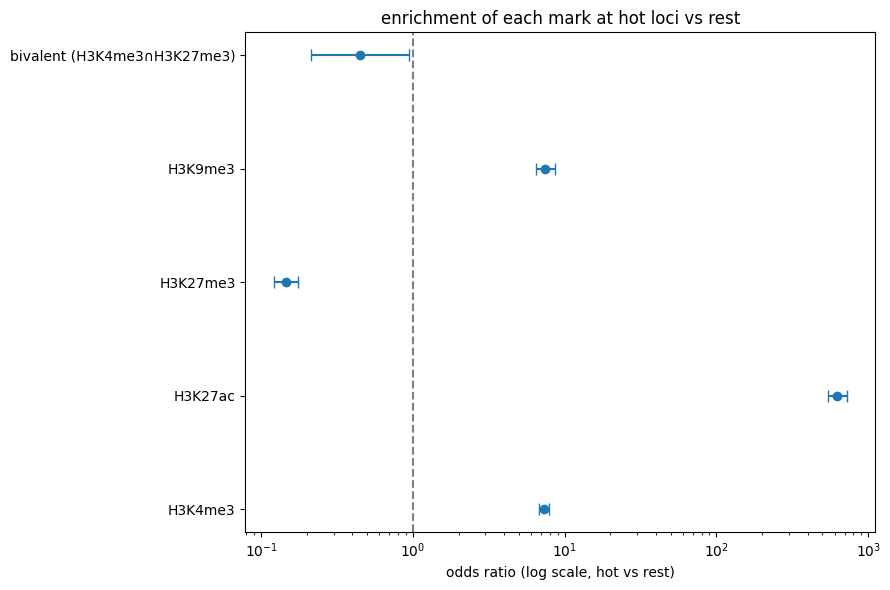

In [10]:
y_pos = np.arange(len(forest_df))

plt.figure(figsize=(9, 6))
plt.errorbar(forest_df['or'], y_pos,
             xerr=[forest_df['or'] - forest_df['ci_lower'], forest_df['ci_upper'] - forest_df['or']],
             fmt='o', capsize=4)
plt.yticks(y_pos, forest_df['mark'])
plt.axvline(1, color='grey', linestyle='--')
plt.xscale('log')
plt.xlabel('odds ratio (log scale, hot vs rest)')
plt.title('enrichment of each mark at hot loci vs rest')
plt.tight_layout()
plt.savefig('plot6_forest.png', dpi=300)
plt.show()

assign occupancy percentile bins on the already-built df_clean/clean_bt

In [11]:
edges = (0, 50, 80, 90, 95, 99, 100)
quantiles = [e / 100 for e in edges]
bin_edges = df_clean['n_tfs'].quantile(quantiles).values
labels = [f'{edges[i]}-{edges[i+1]}' for i in range(len(edges) - 1)]

df_clean['occupancy_bin'] = pd.cut(df_clean['n_tfs'], bins=bin_edges, labels=labels,
                                     include_lowest=True, duplicates='drop')
df_clean['occupancy_bin'].value_counts().sort_index()

occupancy_bin
0-50      375483
50-80     112304
80-90      48007
90-95      28740
95-99      23752
99-100      5916
Name: count, dtype: int64

binary overlap (%) by occupancy bin, per mark -- the core non-circular comparison: are repressive marks enriched at high occupancy the same way active marks are, or not

In [12]:
clean_bt = BedTool.from_dataframe(
    df_clean[['chrom', 'start', 'end', 'occupancy_bin']].astype({'occupancy_bin': str})
).sort(g=genome)

overlap_rows = []
for mark_name, mark_bt in marks.items():
    hits = clean_bt.intersect(mark_bt, c=True)
    hits_df = hits.to_dataframe(names=['chrom', 'start', 'end', 'occupancy_bin', 'overlap_count'])
    hits_df['overlaps'] = hits_df['overlap_count'] > 0
    summary = hits_df.groupby('occupancy_bin', observed=True)['overlaps'].mean().mul(100)
    for b, pct in summary.items():
        overlap_rows.append({'mark': mark_name, 'occupancy_bin': b, 'pct_overlap': pct})

overlap_df = pd.DataFrame(overlap_rows)
overlap_df

,mark,occupancy_bin,pct_overlap
0,H3K4me3,0-50,1.798750
1,H3K4me3,50-80,2.223429
2,H3K4me3,80-90,2.810007
3,H3K4me3,90-95,3.535143
4,H3K4me3,95-99,6.824688
5,H3K4me3,99-100,14.435429
6,H3K27ac,0-50,0.559546
7,H3K27ac,50-80,1.530667
8,H3K27ac,80-90,4.972192
9,H3K27ac,90-95,17.226862


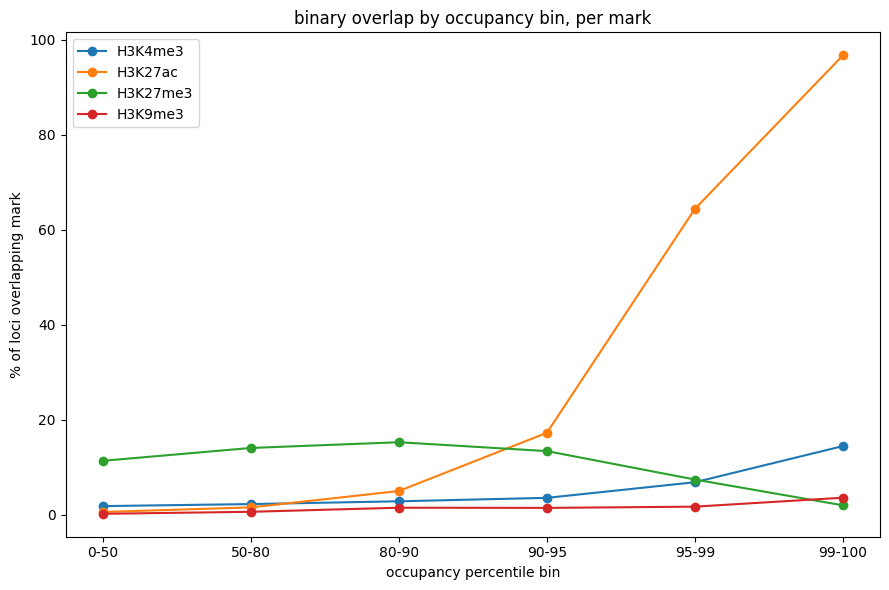

In [13]:
bin_order = list(df_clean['occupancy_bin'].cat.categories)

plt.figure(figsize=(9, 6))
for mark_name in marks:
    sub = overlap_df[overlap_df['mark'] == mark_name].set_index('occupancy_bin').reindex(bin_order)
    plt.plot(bin_order, sub['pct_overlap'], marker='o', label=mark_name)

plt.xlabel('occupancy percentile bin')
plt.ylabel('% of loci overlapping mark')
plt.title('binary overlap by occupancy bin, per mark')
plt.legend()
plt.tight_layout()
plt.savefig('plot5_overlap_by_bin.png', dpi=300)
plt.show()